In [1]:
import numpy as np
import matplotlib.pyplot as plt

def get_neighbors(data, point_idx, eps):
    """Finds the indices of all points within distance 'eps' of the target point."""
    neighbors = []
    for i in range(len(data)):
        # Euclidean distance
        dist = np.linalg.norm(data[point_idx] - data[i])
        if dist <= eps:
            neighbors.append(i)
    return neighbors

In [2]:
def dbscan_from_scratch(data, eps, min_samples):
    # -1 means 'Unvisited', 0 means 'Noise', 1, 2, 3... are Cluster IDs
    labels = np.full(len(data), -1) 
    cluster_id = 0
    
    for i in range(len(data)):
        # If the point was already visited, skip it
        if labels[i] != -1:
            continue
            
        # Find neighbors
        neighbors = get_neighbors(data, i, eps)
        
        # If not enough neighbors, label as Noise (for now)
        if len(neighbors) < min_samples:
            labels[i] = 0
        else:
            # It's a Core Point! Start a new cluster
            cluster_id += 1
            labels[i] = cluster_id
            
            # Now "expand" the cluster to the neighbors
            seed_set = neighbors.copy()
            seed_set.remove(i) # Don't process the current point twice
            
            for n_idx in seed_set:
                # If it was labeled Noise, change it to Border point
                if labels[n_idx] == 0:
                    labels[n_idx] = cluster_id
                
                # If it hasn't been visited, process it
                if labels[n_idx] == -1:
                    labels[n_idx] = cluster_id
                    
                    # Find neighbors of this neighbor
                    new_neighbors = get_neighbors(data, n_idx, eps)
                    if len(new_neighbors) >= min_samples:
                        # If the neighbor is also a Core Point, add its friends to the seed_set
                        seed_set.extend(new_neighbors)
                        
    return labels

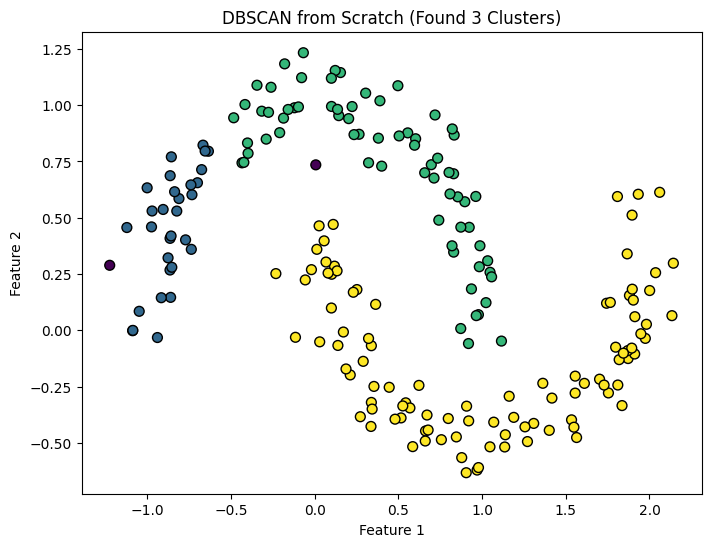

In [3]:
from sklearn.datasets import make_moons

# Create a tricky 'Moon' dataset
X, _ = make_moons(n_samples=200, noise=0.1, random_state=42)

labels = dbscan_from_scratch(X, eps=0.2, min_samples=5)

# Plotting the results
plt.figure(figsize=(8, 6))
# Noise points (0) will be black, clusters will be colored
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, edgecolor='k')
plt.title(f"DBSCAN from Scratch (Found {len(set(labels)) - (1 if 0 in labels else 0)} Clusters)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()